In [8]:
# !  pip install matplotlib
# ! pip install plotly
# ! pip install nbformat
! pip install scikit-learn

##  Análise estatística 

In [9]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mode, hmean, gmean, skew, kurtosis
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'browser'

c = "earthquake_dataset.csv"

df = pd.read_csv(c);

Análise da Coluna: Date (YYYYMMDD)
Coeficiente de Assimetria: -0.04
Coeficiente de Curtose: -1.16
Desvio Padrão: 28506.14
Variância: 812599747.05
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 20198134.72214353
Mediana: 20200510.0
Moda: 20210305
Média Harmônica: 20198094.488261636
Média Geométrica: 20198114.60560764


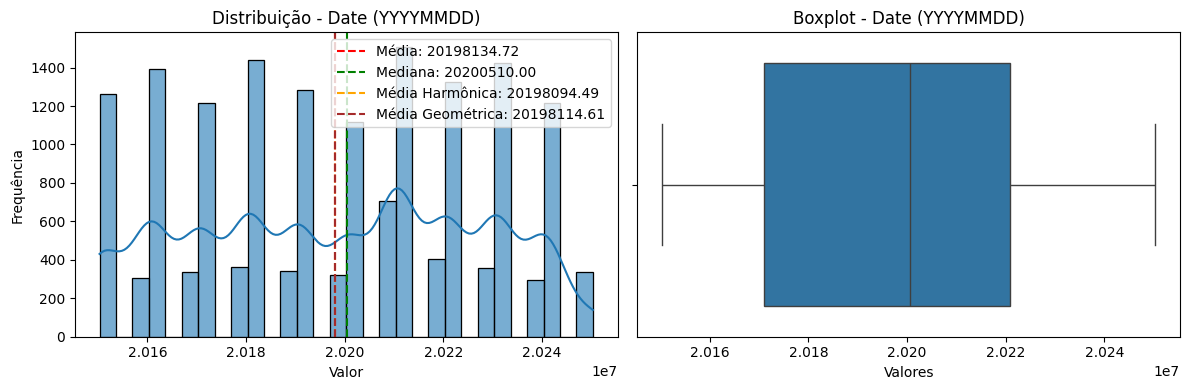

Análise da Coluna: Year
Coeficiente de Assimetria: -0.04
Coeficiente de Curtose: -1.15
Desvio Padrão: 2.85
Variância: 8.15
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 2019.7463999055713
Mediana: 2020.0
Moda: 2021
Média Harmônica: 2019.7423648574932
Média Geométrica: 2019.7443824224247


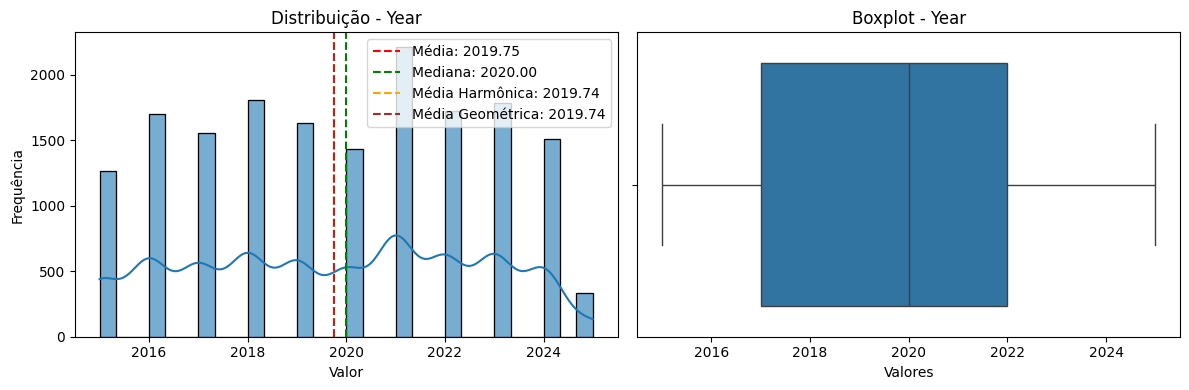

Análise da Coluna: Month
Coeficiente de Assimetria: -0.01
Coeficiente de Curtose: -1.26
Desvio Padrão: 3.52
Variância: 12.40
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 6.554001416430595
Mediana: 7.0
Moda: 12
Média Harmônica: 3.8395199442542998
Média Geométrica: 5.29845638284661


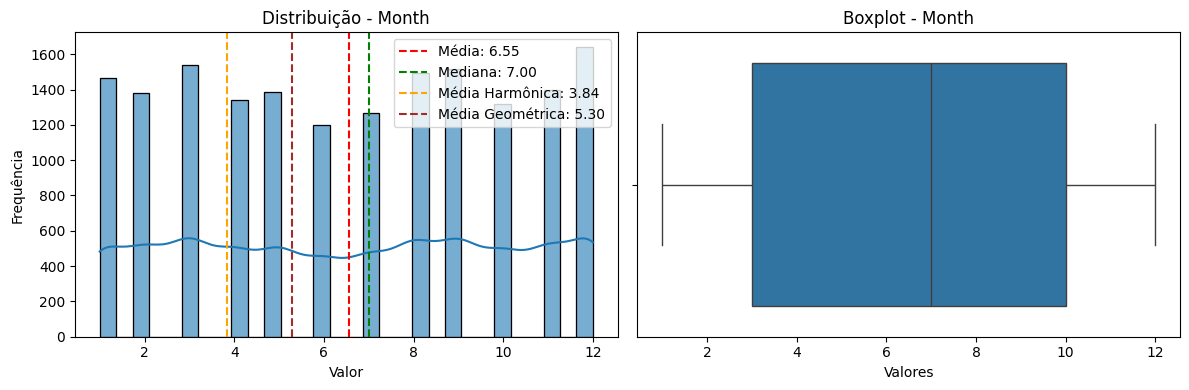

Análise da Coluna: Day
Coeficiente de Assimetria: 0.08
Coeficiente de Curtose: -1.17
Desvio Padrão: 8.70
Variância: 75.78
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 15.322946175637394
Mediana: 15.0
Moda: 5
Média Harmônica: 7.49844402247874
Média Geométrica: 11.895718317467336


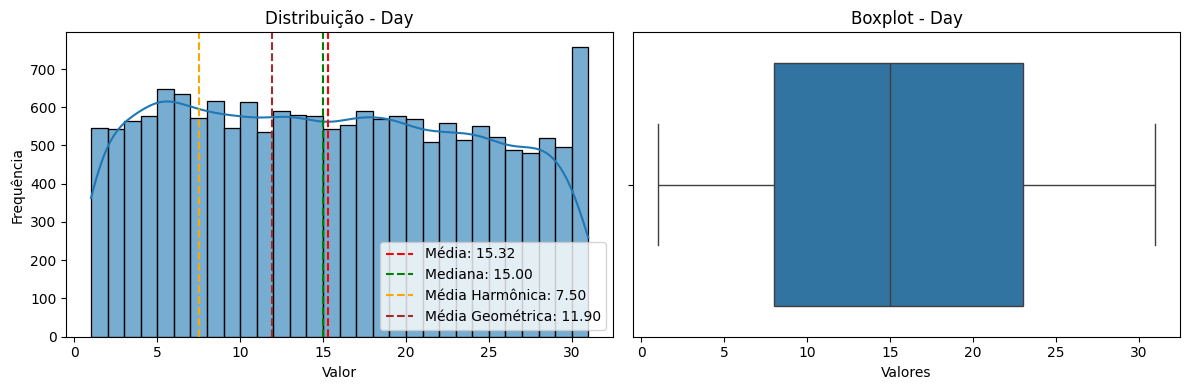

Análise da Coluna: Latitude
Coeficiente de Assimetria: 0.15
Coeficiente de Curtose: -0.51
Desvio Padrão: 30.58
Variância: 935.12
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: -3.207031967359341
Mediana: -5.8123000000000005
Moda: -6.0


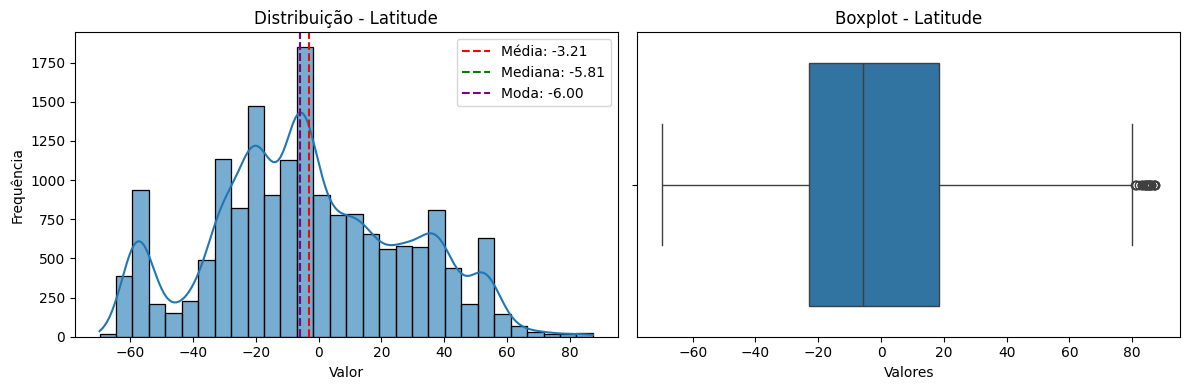

Análise da Coluna: Longitude
Coeficiente de Assimetria: -0.49
Coeficiente de Curtose: -1.29
Desvio Padrão: 123.92
Variância: 15356.87
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 31.839993782235798
Mediana: 87.3783
Moda: 127.0


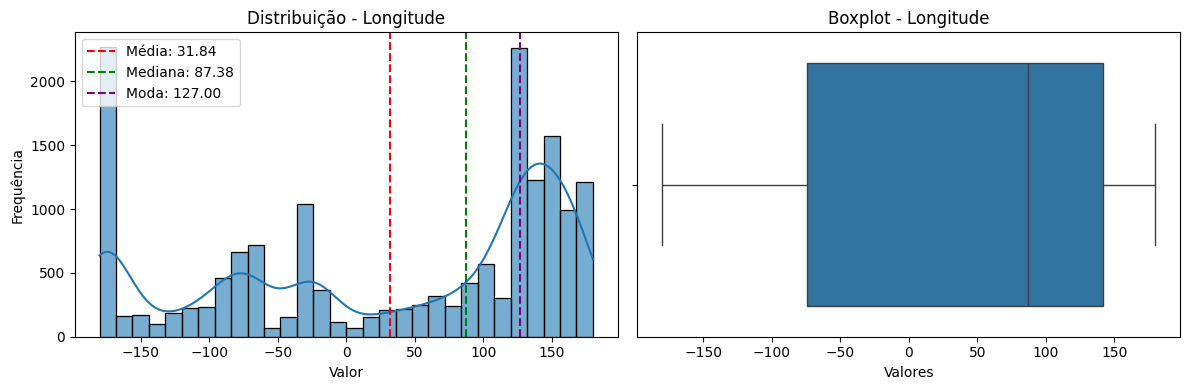

Análise da Coluna: Earthquake Magnitude
Coeficiente de Assimetria: 2.14
Coeficiente de Curtose: 6.26
Desvio Padrão: 0.40
Variância: 0.16
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 5.333485009442871
Mediana: 5.2
Moda: 5.0
Média Harmônica: 5.306723941551641
Média Geométrica: 5.319517308721593


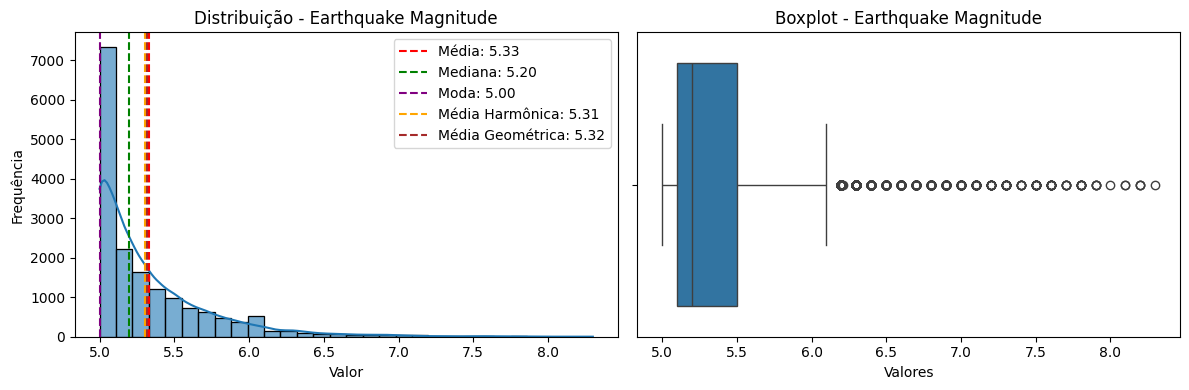

Análise da Coluna: Depth (km)
Coeficiente de Assimetria: 3.87
Coeficiente de Curtose: 15.63
Desvio Padrão: 104.09
Variância: 10834.92
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 53.202267457956616
Mediana: 11.8925
Moda: 10.0


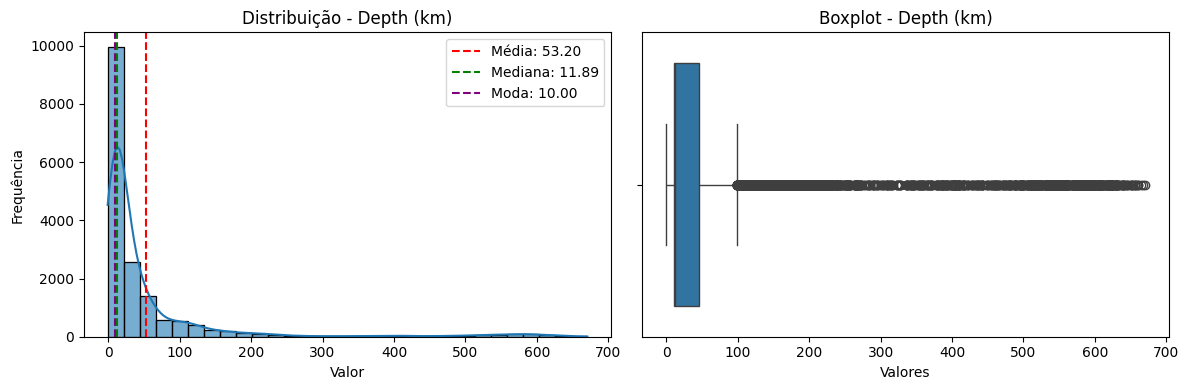

Análise da Coluna: Impact Score
Coeficiente de Assimetria: 7.69
Coeficiente de Curtose: 91.82
Desvio Padrão: 137.23
Variância: 18832.62
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 455.2163597733711
Mediana: 416.0
Moda: 385
Média Harmônica: 437.5522853638125
Média Geométrica: 444.41433593613795


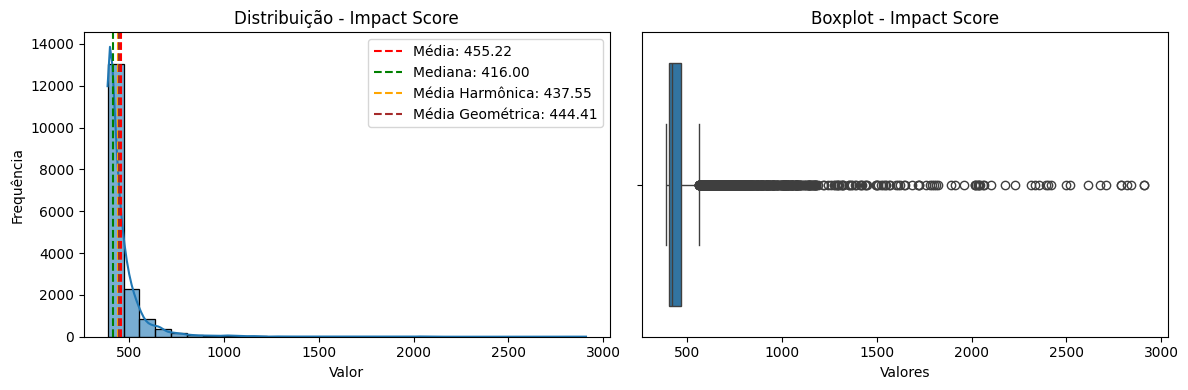

In [10]:
def plot_distribution_side_by_side(population, measures, column_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(population, bins=30, kde=True, alpha=0.6, ax=axes[0])
    colors = ['red', 'green', 'purple', 'orange', 'brown']
    centrality_measures = calculate_centrality_measures(population, measures)

    print("Medidas de Centralidade Calculadas:")
    for measure, value in centrality_measures.items():
        print(f"{measure}: {value}")

    for i, (label, value) in enumerate(centrality_measures.items()):
        if isinstance(value, (int, float, np.floating)):
            axes[0].axvline(value, color=colors[i % len(colors)], linestyle='--', label=f'{label}: {value:.2f}')

    axes[0].set_xlabel("Valor")
    axes[0].set_ylabel("Frequência")
    axes[0].set_title(f"Distribuição - {column_name}")
    axes[0].legend()
    sns.boxplot(x=population, ax=axes[1])
    axes[1].set_title(f'Boxplot - {column_name}')
    axes[1].set_xlabel('Valores')
    plt.tight_layout()
    plt.show()

def calculate_centrality_measures(data, measures):
    results = {}
    data = np.array(data)
    if 'Média' in measures:
        results['Média'] = np.mean(data)
    if 'Mediana' in measures:
        results['Mediana'] = np.median(data)
    if 'Moda' in measures:
        rounded_data = np.round(data)
        mode_result = mode(rounded_data, keepdims=True)
        if len(mode_result.count) > 0 and mode_result.count[0] > 1:
            results['Moda'] = mode_result.mode[0]
        else:
            results['Moda'] = 'Nenhuma moda definida'
    if 'Média Harmônica' in measures and np.all(data > 0):
        results['Média Harmônica'] = hmean(data[data > 0])
    if 'Média Geométrica' in measures and np.all(data > 0):
        results['Média Geométrica'] = gmean(data[data > 0])
    return results

def analyze_data(data, title):
    skew_value = skew(data)
    kurt_value = kurtosis(data)
    std_value = np.std(data)
    var_value = np.var(data)
    print(f"{title}")
    print(f"Coeficiente de Assimetria: {skew_value:.2f}")
    print(f"Coeficiente de Curtose: {kurt_value:.2f}")
    print(f"Desvio Padrão: {std_value:.2f}")
    print(f"Variância: {var_value:.2f}")
    print("--------------------------------------------------")

# PROCESSAR COLUNA DATE
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day

# GARANTIR OS TIPOS NUMÉRICOS DAS COLUNAS
for col in ['Year', 'Month', 'Day', 'Latitude', 'Longitude', 'Earthquake Magnitude', 'Depth (km)', 'Impact Score']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# LISTA FINAL DE COLUNAS PARA ANÁLISE
selected_columns = ['Date', 'Year', 'Month', 'Day', 'Latitude', 'Longitude', 
                    'Earthquake Magnitude', 'Depth (km)', 'Impact Score']

for column in selected_columns:
    if column in df.columns:
        if column == 'Date':
            # Converter para formato YYYYMMDD, ignorando nulos
            date_numeric = df['Date'].dt.strftime('%Y%m%d').dropna().astype(int)
            analyze_data(date_numeric, "Análise da Coluna: Date (YYYYMMDD)")
            selected_measures = ['Média', 'Mediana', 'Moda', 'Média Harmônica', 'Média Geométrica']
            plot_distribution_side_by_side(date_numeric, selected_measures, "Date (YYYYMMDD)")
        else:
            data_series = df[column].dropna()
            data_array = data_series.to_numpy()
            analyze_data(data_array, f"Análise da Coluna: {column}")
            selected_measures = ['Média', 'Mediana', 'Moda', 'Média Harmônica', 'Média Geométrica']
            plot_distribution_side_by_side(data_array, selected_measures, column)

**Colunas temporais: Year, Month, Day**
Assimetria próxima de zero mostra que os eventos estão uniformemente distribuídos ao longo dos anos/meses/dias.
Curtose negativa aponta para uma distribuição mais “achatada”, sem concentração em valores extremos (sem muitos anos/meses/dias com terremotos fora do comum).
Médias próximas das medianas, indicando poucas distorções por outliers temporais.


Latitude e Longitude

Latitude tem média negativa (eventos mais ao Hemisfério Sul), mas dados bem distribuídos (assimetria baixa), enquanto longitude tem mais distribuição para valores mais baixos.
Curtoses negativas significam menos valores extremos: a maioria dos terremotos ocorre em regiões geográficas parecidas.
Magnitude

Os dados geográficos mostram predominância de eventos no Hemisfério Sul, com média negativa para a latitude, mas boa dispersão devido à baixa assimetria. Para longitude, observa-se maior concentração em valores mais baixos, possivelmente refletindo a presença de placas tectônicas ou zonas sísmicas mais ativas em longitudes específicas. As curtoses negativas em ambas as variáveis indicam ausência de regiões com concentração extrema de terremotos, o que sugere distribuição geográfica relativamente homogênea.


Assimetria positiva alta (2.14): Existem muito mais eventos de baixa magnitude do que de alta (eventos intensos são raros).
Curtose alta (6.26): Muitas observações são próximas da média com algumas poucas magnitudes muito altas.
Média próxima da mediana: Distribuição estável, mas com cauda longa para magnitudes altas.
Profundidade

Assimetria fortemente positiva (3.87): A maioria dos terremotos ocorre em profundidades baixas, mas há poucos muito profundos.

Curtose extremamente alta (15.63): Existem outliers extremos, provavelmente poucos terremotos muito profundos.
Média maior que a mediana: Mostra que poucos terremotos profundos aumentam bastante a média.
Impact Score

Assimetria e curtose altíssimas: A maioria dos eventos tem impacto menor, mas existem alguns eventos catastróficos, verdadeiros outliers.


In [11]:
import pandas as pd

# Caminho do arquivo CSV
csv_path = "earthquake_dataset.csv"

# Lê o CSV
df = pd.read_csv(csv_path)

# Mostra os tipos de variáveis de cada coluna
print("Tipos de variáveis no dataset:")
for col in df.columns:
    dtype = df[col].dtype
    if pd.api.types.is_numeric_dtype(df[col]):
        tipo = "Numérica"
    elif pd.api.types.is_datetime64_any_dtype(df[col]):
        tipo = "Data/Hora"
    else:
        tipo = "Categórica (Texto)"
    print(f"{col}: {tipo} ({dtype})")

Tipos de variáveis no dataset:
Date: Categórica (Texto) (object)
Time (UTC): Categórica (Texto) (object)
City: Categórica (Texto) (object)
Country: Categórica (Texto) (object)
Latitude: Numérica (float64)
Longitude: Numérica (float64)
Earthquake Magnitude: Numérica (float64)
Depth (km): Numérica (float64)
Impact Score: Numérica (int64)


In [12]:
csv_path = "earthquake_dataset.csv"

# Lê o CSV
df = pd.read_csv(csv_path)

def verificar_valores_nao_numericos_lat_lon(df, lat_col='Latitude', lon_col='Longitude'):
    """
    Verifica se há valores não numéricos nas colunas de latitude e longitude do DataFrame.
    Retorna True se houver algum valor não numérico, senão False.
    Também exibe os valores problemáticos encontrados.
    """
    lat_nao_numericos = df[~df[lat_col].apply(lambda x: pd.to_numeric(x, errors='coerce')).notnull()]
    lon_nao_numericos = df[~df[lon_col].apply(lambda x: pd.to_numeric(x, errors='coerce')).notnull()]

    if not lat_nao_numericos.empty:
        print(f"Valores não numéricos encontrados na coluna '{lat_col}':")
        print(lat_nao_numericos[lat_col].unique())

    if not lon_nao_numericos.empty:
        print(f"Valores não numéricos encontrados na coluna '{lon_col}':")
        print(lon_nao_numericos[lon_col].unique())

    return not lat_nao_numericos.empty or not lon_nao_numericos.empty

# Exemplo de uso:
tem_nao_numericos = verificar_valores_nao_numericos_lat_lon(df, lat_col='Latitude', lon_col='Longitude')
if tem_nao_numericos:
    print("Existem valores não numéricos em Latitude ou Longitude.")
else:
    print("Todas as entradas de Latitude e Longitude são numéricas.")

Todas as entradas de Latitude e Longitude são numéricas.


In [13]:
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day

# 1. Latitude vs Longitude
fig1 = px.scatter(df, x='Longitude', y='Latitude', 
                  title='Dispersão dos Terremotos (Latitude x Longitude)',
                  labels={'Longitude':'Longitude', 'Latitude':'Latitude'},
                  color='Earthquake Magnitude',
                  hover_data=['City','Country','Earthquake Magnitude'])
fig1.show()

# 2. Profundidade vs Magnitude
fig2 = px.scatter(df, x='Depth (km)', y='Earthquake Magnitude',
                  title='Magnitude do Terremoto vs Profundidade',
                  labels={'Depth (km)':'Profundidade (km)', 'Earthquake Magnitude':'Magnitude'},
                  color='Earthquake Magnitude',
                  hover_data=['City','Country','Impact Score'])
fig2.show()

# 3. Magnitude vs Impact Score
fig3 = px.scatter(df, x='Earthquake Magnitude', y='Impact Score',
                  title='Magnitude do Terremoto vs Impacto',
                  labels={'Earthquake Magnitude':'Magnitude', 'Impact Score':'Impacto'},
                  color='Earthquake Magnitude',
                  hover_data=['City','Country','Depth (km)'])
fig3.show()

# 4. Ano vs Magnitude
fig4 = px.scatter(df, x='Year', y='Earthquake Magnitude',
                  title='Ano vs Magnitude dos Terremotos',
                  labels={'Year':'Ano', 'Earthquake Magnitude':'Magnitude'},
                  color='Earthquake Magnitude',
                  hover_data=['City','Country','Depth (km)'])
fig4.show()

                          Year     Month       Day  Latitude  Longitude  \
Year                  1.000000 -0.120835 -0.043928  0.002107  -0.007548   
Month                -0.120835  1.000000 -0.002093 -0.013416   0.014327   
Day                  -0.043928 -0.002093  1.000000  0.021126   0.000862   
Latitude              0.002107 -0.013416  0.021126  1.000000   0.206431   
Longitude            -0.007548  0.014327  0.000862  0.206431   1.000000   
Earthquake Magnitude -0.033242  0.018531  0.005683  0.008795  -0.026573   
Depth (km)           -0.002839  0.013413  0.010402 -0.040193  -0.052083   
Impact Score         -0.012966  0.005315  0.008311  0.106140  -0.045092   

                      Earthquake Magnitude  Depth (km)  Impact Score  
Year                             -0.033242   -0.002839     -0.012966  
Month                             0.018531    0.013413      0.005315  
Day                               0.005683    0.010402      0.008311  
Latitude                          0.0087

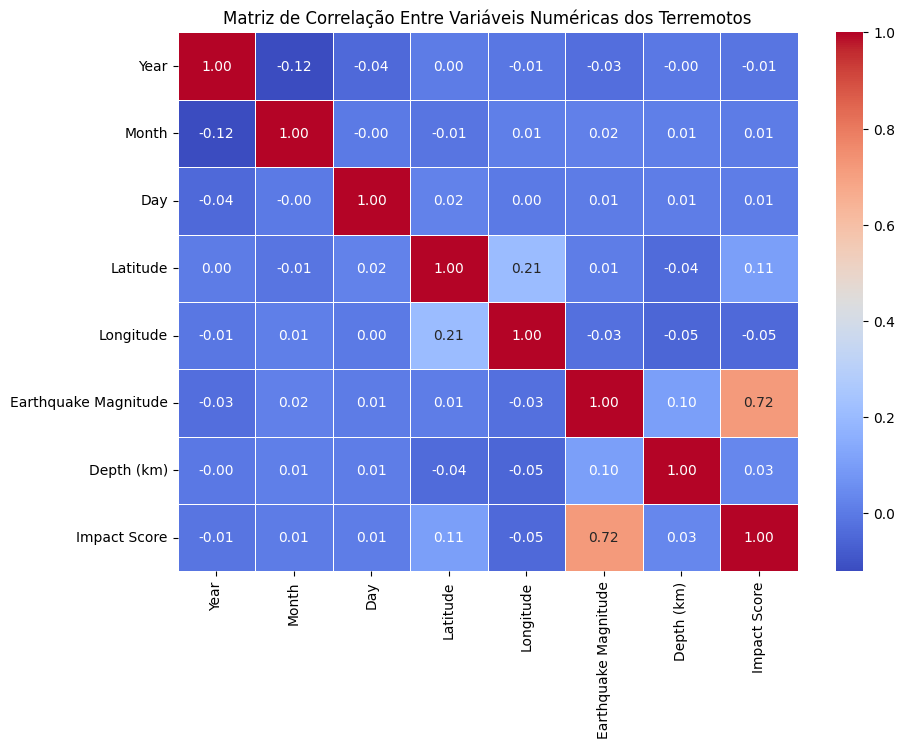

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Supondo que seu DataFrame já tenha as colunas citadas
numeric_cols = ['Year', 'Month', 'Day', 'Latitude', 'Longitude',
                'Earthquake Magnitude', 'Depth (km)', 'Impact Score']

# 1. Cálculo da correlação
corr = df[numeric_cols].corr()

# 2. Exibição da matriz de correlação como tabela
print(corr)

# 3. Visualização do heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação Entre Variáveis Numéricas dos Terremotos')
plt.show()

Equação: Impact Score = 243.7911 * Magnitude + -845.0397
Coeficiente de determinação (R²): 0.5157
Mean Squared Error (MSE): 9120.2211


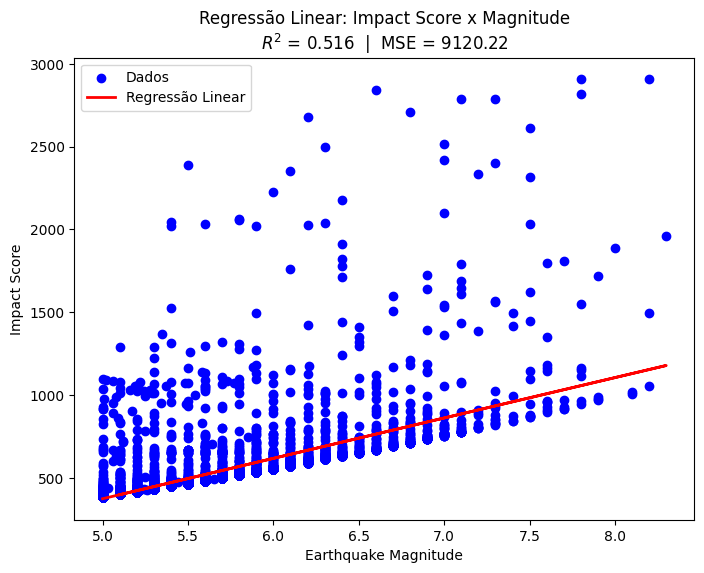

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Prepara os dados, garantindo que não há valores ausentes
df_clean = df[['Earthquake Magnitude', 'Impact Score']].dropna()

X = df_clean[['Earthquake Magnitude']]
y = df_clean['Impact Score']

# Ajusta o modelo
reg = LinearRegression()
reg.fit(X, y)
y_pred = reg.predict(X)

# Coeficientes
a = reg.coef_[0]
b = reg.intercept_
r2 = reg.score(X, y)
mse = mean_squared_error(y, y_pred)

print(f"Equação: Impact Score = {a:.4f} * Magnitude + {b:.4f}")
print(f"Coeficiente de determinação (R²): {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Gráfico
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Dados')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regressão Linear')
plt.xlabel('Earthquake Magnitude')
plt.ylabel('Impact Score')
plt.title(f"Regressão Linear: Impact Score x Magnitude\n$R^2$ = {r2:.3f}  |  MSE = {mse:.2f}")
plt.legend()
plt.show()

## Gráficos usados no trabalho